In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys
import data_analysis.mea_analysis as mea
from sklearn.metrics import accuracy_score
from pathlib import Path

In [10]:
folder_path = Path("/media/ferdinand-forberger/RawDataBackUp/8606_5")

In [11]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"



df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

#get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["sttc_path"] = df_overview["folder_path"] / "sttc.npy"

In [12]:
def find_bxr_path(original_path):
    paths = list(Path(original_path).glob("*.bxr"))
    if len(paths) == 0:
        return None
    else:
        return paths[0]
def find_biggest_brw_file(original_path):
    paths = list(Path(original_path).glob("*.brw"))
    if len(paths) == 0:
        return None
    else:
        sizes = [path.stat().st_size for path in paths]
        return paths[np.argmax(sizes)]

def replace_E(string,path):
    return string.replace("E:\\",str(path )+ "/")

In [13]:
df_overview["original_recording_base_path"] = df_overview["original_recording_base_path"].apply(lambda x: replace_E(x, BRW_BASE_FOLDER))
df_overview["bxr_path"] = df_overview["original_recording_base_path"].apply(lambda x: find_bxr_path(x))
df_overview["brw_path"] = df_overview["original_recording_base_path"].apply(lambda x: find_biggest_brw_file(x))

In [14]:

def get_3brain_data(bxr_path, brw_path):

    bxr_file = h5py.File(bxr_path, 'r')
    Well_A1_keys = np.array(bxr_file["Well_A1"])
    Well_A1 = {}
    for key in Well_A1_keys:
        #print(key)
        arr = bxr_file["Well_A1"][key][:]
        #print(arr.shape)
        Well_A1[key] = arr

    bxr_file.close()

    brw_file = h5py.File(brw_path, 'r')
    sampling_rate = brw_file.attrs['SamplingRate']
    total_samples = brw_file["Well_A1"]["Raw"].shape[0]
    ch_indices = np.array(brw_file['Well_A1']["StoredChIdxs"])  # Shape (4096,)
    n_channels = len(ch_indices)
    total_samples = total_samples // n_channels
    total_duration_sec = total_samples / sampling_rate
    total_samples
    brw_file.close()

    return Well_A1, sampling_rate,total_duration_sec


In [81]:
import traceback
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [82]:

recs_to_compare = [
    "8606_1",
    "8606_2",
    "8606_5",
    "8606_6",
    "8602_2",
    "8602_1",
    "8602_5",
    "8602_6" ]

df_overview = df_overview[df_overview["folder"].isin(recs_to_compare)]
df_overview.reset_index(inplace=True, drop=True)

overall_metrics = {}
for idx, row in df_overview.iterrows():
    try:
        metrics = {}
        print(f"Processing {row['folder']} ({idx+1}/{len(df_overview)})")

        Well_A1, sampling_rate, total_duration_sec = get_3brain_data(bxr_path=row["bxr_path"], brw_path=row["brw_path"])
        
        # NB durations

        nbs_3brain = Well_A1["SpikeNetworkBurstTimes"]
        starts = nbs_3brain[:, 0]
        ends = nbs_3brain[:, 1]
        starts, ends, _= mea.fuse_NBs(starts, ends, clusters=None, fused_under_sec=0.05) #double check if 0.1 or 0.05
        starts, ends, _ = mea.remove_short_NBs(starts,
                                        ends,
                                        clusters=None,
                                        remove_under_sec=0.1)
        nbs_3brain = np.array(list(zip(starts, ends)))
        metrics["nb_count_3brain"] = len(nbs_3brain)
        metrics["nb_durations_3brain_mean_sec"] = np.mean(ends - starts) / sampling_rate if len(nbs_3brain) > 0 else 0

        nbs_custom = np.load(row["sle_path"]).T.astype(int)
        metrics["nb_count_custom"] = len(nbs_custom)
        
        metrics["nb_durations_custom_mean_sec"] = np.mean(nbs_custom[:,1] - nbs_custom[:,0]) / sampling_rate if len(nbs_custom) > 0 else 0
        
        # NB accuracy
        
        labels_custom = np.zeros(int(total_duration_sec*sampling_rate), dtype=int)
        labels_3brain = labels_custom.copy()
        for i, (start, end) in enumerate(nbs_custom):
            labels_custom[start:end] = 1
        for i, (start, end) in enumerate(nbs_3brain):
            labels_3brain[start:end] = 1

        accuracy = accuracy_score(labels_custom, labels_3brain)
        precision = precision_score(labels_custom, labels_3brain)
        recall = recall_score(labels_custom, labels_3brain)

        metrics["nb_accuracy"] = accuracy
        metrics["nb_precision"] = precision
        metrics["nb_recall"] = recall

        overall_metrics[row["folder"]] = metrics

        #graph metrics
        sttc_custom = np.load(row["sttc_path"])

        #st_df = get_stdf(parent_folder_path=row["folder_path"])
    except Exception as e:
        #print error traceback


        print(f"Error processing {row['folder']}: {e}")
        print(traceback.format_exc())
        continue

Processing 8602_1 (1/8)
Remove uznder sec 0.1
Processing 8602_2 (2/8)
Error processing 8602_2: 'SpikeNetworkBurstTimes'
Traceback (most recent call last):
  File "/tmp/ipykernel_8872/2087798456.py", line 24, in <module>
    nbs_3brain = Well_A1["SpikeNetworkBurstTimes"]
                 ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyError: 'SpikeNetworkBurstTimes'

Processing 8602_5 (3/8)
Remove uznder sec 0.1
Processing 8602_6 (4/8)
Remove uznder sec 0.1
Processing 8606_1 (5/8)
Remove uznder sec 0.1
Processing 8606_2 (6/8)
Remove uznder sec 0.1
Processing 8606_5 (7/8)
Remove uznder sec 0.1
Processing 8606_6 (8/8)
Remove uznder sec 0.1


In [ ]:
bxr_file = h5py.File(row["bxr_path"], 'r')
Well_A1_keys = np.array(bxr_file["Well_A1"])
import json
settings_brainwave = json.loads(bxr_file["ExperimentInfo"][:][0])
#save json
json.dump(settings_brainwave, open("brainwave_settings/brainwave_settings.json", 'w'), indent=4)

In [84]:
nb_comparision = pd.DataFrame(overall_metrics).T

In [86]:
nb_comparision.columns

Index(['nb_count_3brain', 'nb_durations_3brain_mean_sec', 'nb_count_custom',
       'nb_durations_custom_mean_sec', 'nb_accuracy', 'nb_precision',
       'nb_recall'],
      dtype='object')

In [88]:
better_column_order = [
    "nb_count_custom",
    "nb_count_3brain",
    "nb_durations_custom_mean_sec",
    "nb_durations_3brain_mean_sec",
    "nb_accuracy",
    "nb_precision",
    "nb_recall"]
nb_comparision = nb_comparision[better_column_order]
nb_comparision

,nb_count_custom,nb_count_3brain,nb_durations_custom_mean_sec,nb_durations_3brain_mean_sec,nb_accuracy,nb_precision,nb_recall
8602_1,53.0,51.0,0.455477,0.254984,0.980942,0.988508,0.532502
8602_5,150.0,117.0,0.350785,0.355188,0.978946,0.981090,0.774856
8602_6,202.0,158.0,0.387573,0.392040,0.967919,0.976580,0.772664
8606_1,59.0,59.0,0.451083,0.311844,0.981516,0.921867,0.637308
8606_2,58.0,60.0,0.842579,0.868473,0.992199,0.924013,0.985251
8606_5,119.0,140.0,0.817976,0.655470,0.974068,0.945591,0.891450
8606_6,152.0,162.0,0.910935,0.711810,0.952077,0.975697,0.812574


In [89]:
nb_comparision.to_excel("data/nb_comparision.xlsx")

In [16]:
SAMPLING_RATE = sampling_rate
from kilosort.run_kilosort import CCG, load_sorting

In [26]:
SpikeUnits = Well_A1["SpikeUnits"].copy()
SpikeTimes = Well_A1["SpikeTimes"].copy()

mask = SpikeUnits>=0
SpikeUnits = SpikeUnits[mask]
SpikeTimes = SpikeTimes[mask]



print(SpikeUnits.shape)
unit_freqs = pd.Series(SpikeUnits).value_counts().sort_index()
unit_freqs = pd.DataFrame(unit_freqs)
print(unit_freqs.shape)
unit_freqs["freq"] = unit_freqs / total_duration_sec
mask = unit_freqs["freq"].values > 1
filered_unique_units = unit_freqs.index[mask]

mask_spikes = np.isin(SpikeUnits, filered_unique_units)
SpikeUnits_filtered = SpikeUnits[mask_spikes].copy()
SpikeTimes_filtered = SpikeTimes[mask_spikes].copy()
print(f"SpikeUnits shape: {SpikeUnits.shape} -> {SpikeUnits_filtered.shape}")
print(f"SpikeTimes shape: {SpikeTimes.shape} -> {SpikeTimes_filtered.shape}")



(772555,)
(10508, 1)
SpikeUnits shape: (772555,) -> (539280,)
SpikeTimes shape: (772555,) -> (539280,)


In [29]:
row

folder                                                                     8606_6
folder_path                     /media/ferdinand-forberger/Seagate Portable Dr...
bin_path_x                      /media/ferdinand-forberger/Seagate Portable Dr...
analyzed                                                                     True
sle_path                        /media/ferdinand-forberger/Seagate Portable Dr...
sles_saved                                                                   True
image_path                      /media/ferdinand-forberger/Seagate Portable Dr...
mask_path                       /media/ferdinand-forberger/Seagate Portable Dr...
animal_number                                                                8606
slice_number                                                                    6
analyzed_bool                                                                True
original_recording_base_path      /media/ferdinand-forberger/RawDataBackUp/8606_6
target_folder_ba

In [34]:
from spikeinterface.extractors import NumpySorting
from spikeinterface.comparison import compare_two_sorters

In [36]:
SpikeTimes

array([    1999,     2118,     2323, ..., 11851680, 11851943, 11852094])

In [37]:
st

array([      40,      125,      155, ..., 11852106, 11852151, 11852197])

In [46]:
SpikeUnits[0]

np.int32(10624)

In [67]:
st_df

,clu,num_spikes,chan_best,mua_labels
87,87,21260,3147,mua
158,158,18303,2570,mua
143,143,18063,2699,mua
108,108,17718,3018,mua
94,94,16722,3107,mua
...,...,...,...,...
83,83,101,3187,mua
315,315,101,1290,mua
181,181,101,2460,mua
1,1,92,4014,mua


In [68]:
is_ref_new, _ = CCG.refract(clu, st / SAMPLING_RATE,
                            acg_threshold=0.2)
is_ref_new

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1.

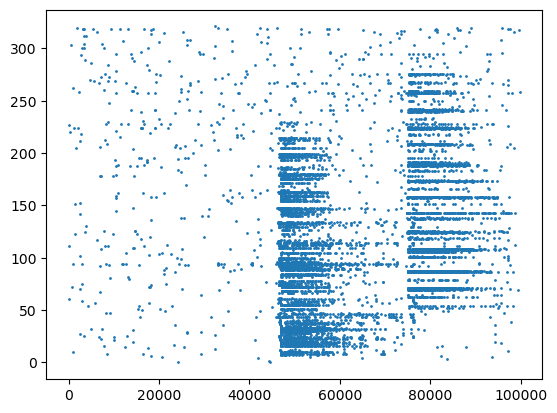

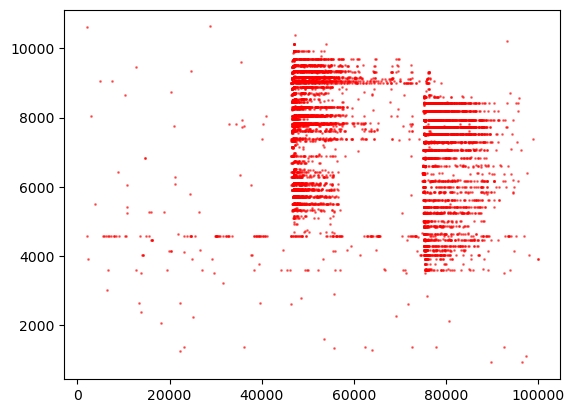

In [78]:
max_index = 100000
plt.figure()
plt.scatter(st[st<max_index], clu[st<max_index], s=1)
plt.show()

plt.figure()
plt.scatter(SpikeTimes[SpikeTimes<max_index], SpikeUnits[SpikeTimes<max_index], s=1, color="red", alpha=0.5)
plt.show()

In [79]:
from data_analysis.graphs import construct_graph

In [ ]:
construct_graph()

In [80]:
st_df

,clu,num_spikes,chan_best,mua_labels
87,87,21260,3147,mua
158,158,18303,2570,mua
143,143,18063,2699,mua
108,108,17718,3018,mua
94,94,16722,3107,mua
...,...,...,...,...
83,83,101,3187,mua
315,315,101,1290,mua
181,181,101,2460,mua
1,1,92,4014,mua


In [77]:
for idx, row in df_overview.iterrows():
    st_df, st, clu, best_cha_st, vectorized_map = mea.get_stdf(row["folder_path"])
    is_ref_kilosort, _ = CCG.refract(clu, st / SAMPLING_RATE,
                            acg_threshold=0.2)
    print(f"There are {np.sum(is_ref_kilosort)} 'good' units present in the Kilosort output")

    Well_A1, sampling_rate, total_duration_sec = get_3brain_data(bxr_path=row["bxr_path"], brw_path=row["brw_path"])
    mask = Well_A1["SpikeUnits"]>=0
    Well_A1["SpikeUnits"] = Well_A1["SpikeUnits"][mask]
    Well_A1["SpikeTimes"] = Well_A1["SpikeTimes"][mask]

    is_ref_brainwave, _ = CCG.refract(Well_A1["SpikeUnits"], Well_A1["SpikeTimes"] / SAMPLING_RATE,
                            acg_threshold=0.2)
    print(f"There are {np.sum(is_ref_brainwave)} 'good' units present in the BrainWave output")

    SpikeUnits = Well_A1["SpikeUnits"].copy()
    SpikeTimes = Well_A1["SpikeTimes"].copy()

    brainwave_sorting = NumpySorting.from_samples_and_labels(samples_list=[SpikeTimes], 
                                                             labels_list=[SpikeUnits],
                                                             sampling_frequency=SAMPLING_RATE)
    
    kilosort_sorting = NumpySorting.from_samples_and_labels(samples_list=[st], 
                                                             labels_list=[clu],
                                                             sampling_frequency=SAMPLING_RATE)
    
    comparison = compare_two_sorters(sorting1=brainwave_sorting, 
                                     sorting2=kilosort_sorting,
                                     delta_time=1)
    
    print(comparison.get_agreement_fraction())


Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Number of good clusters (Original): 114
Number of good clusters (Changed): 114
-------------------------------------------------------
There are 114.0 'good' units present in the Kilosort output
There are 81.0 'good' units present in the BrainWave output
Samples list shape 1
There are (3273,) unique unit ids!


iterating through samples_list!:   0%|          | 0/1 [00:00<?, ?it/s]

enumerating unit ids: 0it [00:00, ?it/s]

Samples list shape 1
There are (350,) unique unit ids!


iterating through samples_list!:   0%|          | 0/1 [00:00<?, ?it/s]

...

enumerating unit ids: 0it [00:00, ?it/s]

Samples list shape 1
There are (323,) unique unit ids!


iterating through samples_list!:   0%|          | 0/1 [00:00<?, ?it/s]

enumerating unit ids: 0it [00:00, ?it/s]

0
